In [45]:
# Initializations
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/data_processed.csv")
df.head()

,game_id,subframe_max,subframe_count,cleared_sum,garbage_cleared_sum,attack_sum,t_spin_count,btb_mean,btb_max,combo_mean,...,incoming_garbage_max,won,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,1,42360,196,115,0,161,15,1.933673,8,0.520408,...,15,1,24748.521,2701.8877,62.212624,70.600000,2.776204,0.821429,136.827195,0.076531
1,2,42786,215,133,0,126,12,0.413953,4,0.590698,...,13,0,24820.710,2791.8670,63.886936,71.310000,3.015005,0.586047,106.015987,0.055814
2,3,29565,152,85,0,102,10,0.611842,3,0.605263,...,6,1,24820.710,2791.8670,63.886936,49.275000,3.084729,0.671053,124.200913,0.065789
3,4,29570,136,83,0,85,5,0.786765,4,0.588235,...,10,0,24748.521,2701.8877,62.212624,49.283333,2.759554,0.625000,103.483260,0.036765
4,5,41715,191,107,0,128,11,1.277487,7,0.539267,...,11,1,24748.521,2701.8877,62.212624,69.525000,2.747213,0.670157,110.463862,0.057592


In [46]:
# Data Overview and Quality
df.info()
df.describe(include="all")
print("Missing values per column:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70246 entries, 0 to 70245
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 70246 non-null  int64  
 1   subframe_max            70246 non-null  int64  
 2   subframe_count          70246 non-null  int64  
 3   cleared_sum             70246 non-null  int64  
 4   garbage_cleared_sum     70246 non-null  int64  
 5   attack_sum              70246 non-null  int64  
 6   t_spin_count            70246 non-null  int64  
 7   btb_mean                70246 non-null  float64
 8   btb_max                 70246 non-null  int64  
 9   combo_mean              70246 non-null  float64
 10  combo_max               70246 non-null  int64  
 11  immediate_garbage_mean  70246 non-null  float64
 12  immediate_garbage_max   70246 non-null  int64  
 13  incoming_garbage_mean   70246 non-null  float64
 14  incoming_garbage_max    70246 non-null

### What is the Distribution of Winning and Losing Games?

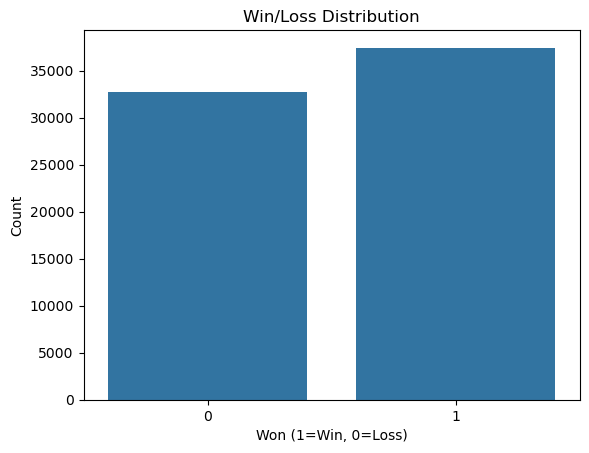

won
1    0.533183
0    0.466817
Name: proportion, dtype: float64

In [47]:
sns.countplot(x="won", data=df)
plt.title("Win/Loss Distribution")
plt.xlabel("Won (1=Win, 0=Loss)")
plt.ylabel("Count")
plt.show()

df["won"].value_counts(normalize=True)

### What is the Distribution of Player Ratings?

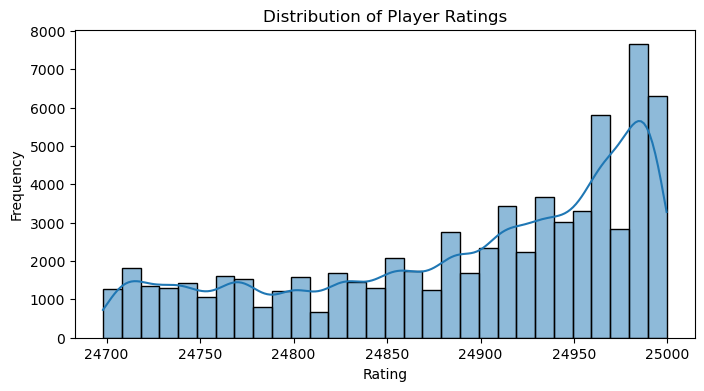

In [48]:
plt.figure(figsize=(8, 4))
sns.histplot(df["rating"], kde=True, bins=30)
plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

### What is the Distrbution of Game Lengths in Seconds?

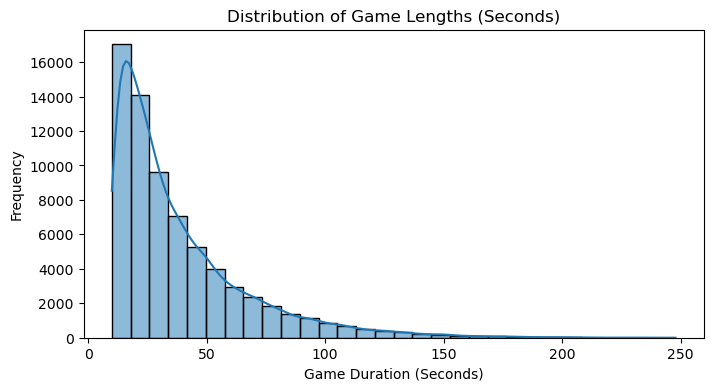

In [49]:
plt.figure(figsize=(8, 4))
sns.histplot(df["duration_sec"], kde=True, bins=30)
plt.title("Distribution of Game Lengths (Seconds)")
plt.xlabel("Game Duration (Seconds)")
plt.ylabel("Frequency")
plt.show()

### What is the distribution of Pieces Per Second (PPS) and Attack Per Minute (APM)?

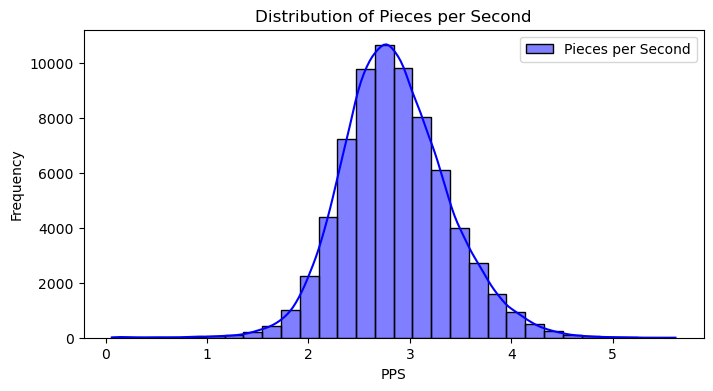

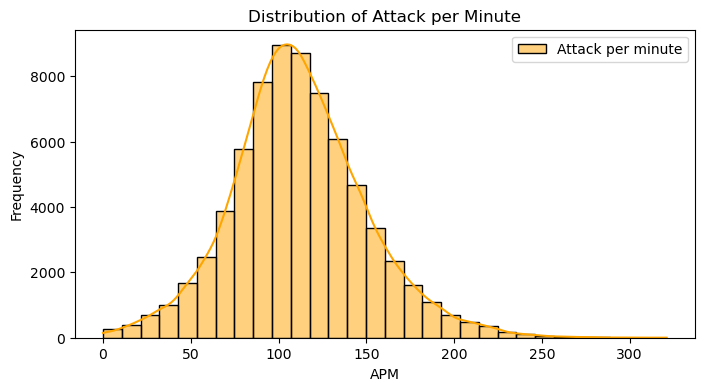

In [50]:
plt.figure(figsize=(8, 4))
sns.histplot(df["pps"], kde=True, color="blue",
             bins=30, label="Pieces per Second")
plt.title("Distribution of Pieces per Second")
plt.xlabel("PPS")
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    df["apm"], kde=True, color="orange", bins=30, label="Attack per minute"
)
plt.title("Distribution of Attack per Minute")
plt.xlabel("APM")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### How does average Attack Per Minute (APM) differ between winning games and losing games?

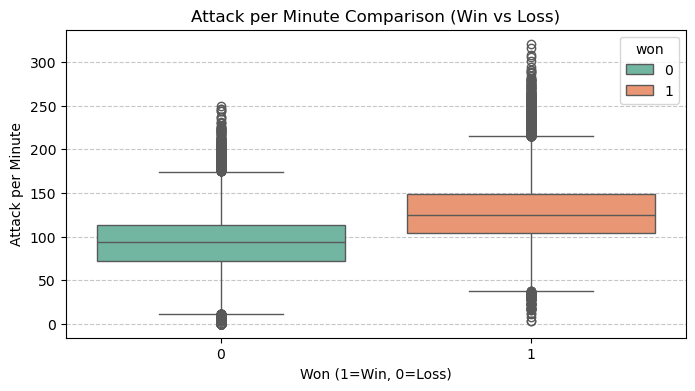

In [51]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    x="won",
    y="apm",
    data=df,
    hue="won",
    palette="Set2",
    dodge=False,
)
plt.title("Attack per Minute Comparison (Win vs Loss)")
plt.xlabel("Won (1=Win, 0=Loss)")
plt.ylabel("Attack per Minute")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Do winning games exhibit a higher average Attack Efficiency (garbage sent per piece) than losing games?

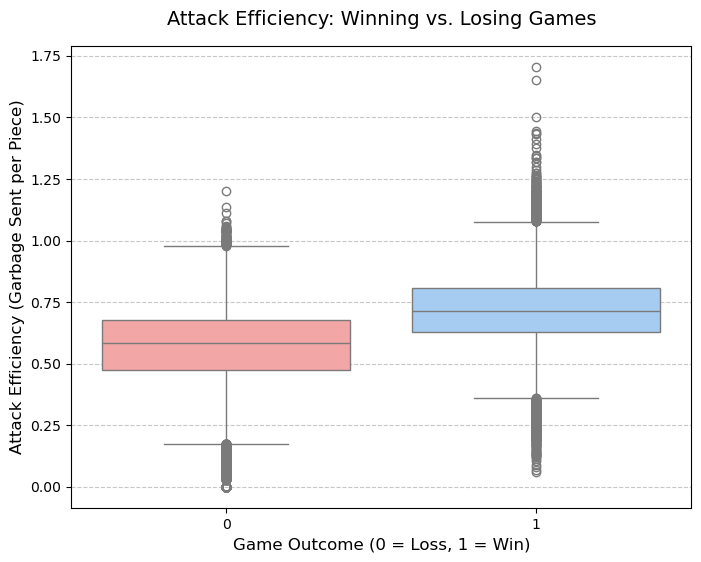

       count      mean       std       min       25%       50%       75%  \
won                                                                        
0    32792.0  0.566540  0.164676  0.000000  0.475560  0.584746  0.676471   
1    37454.0  0.717233  0.142973  0.058824  0.628099  0.715190  0.807692   

          max  
won            
0    1.200000  
1    1.705882  


In [52]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="won",
    y="attack_per_piece",
    hue="won",
    data=df,
    palette=["#FF9999", "#99CCFF"],
    legend=False
)

plt.title("Attack Efficiency: Winning vs. Losing Games", fontsize=14, pad=15)
plt.xlabel("Game Outcome (0 = Loss, 1 = Win)", fontsize=12)
plt.ylabel("Attack Efficiency (Garbage Sent per Piece)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print(df.groupby("won")["attack_per_piece"].describe())

### How does the T-Spin Rate differ between games that were won versus games that were lost?

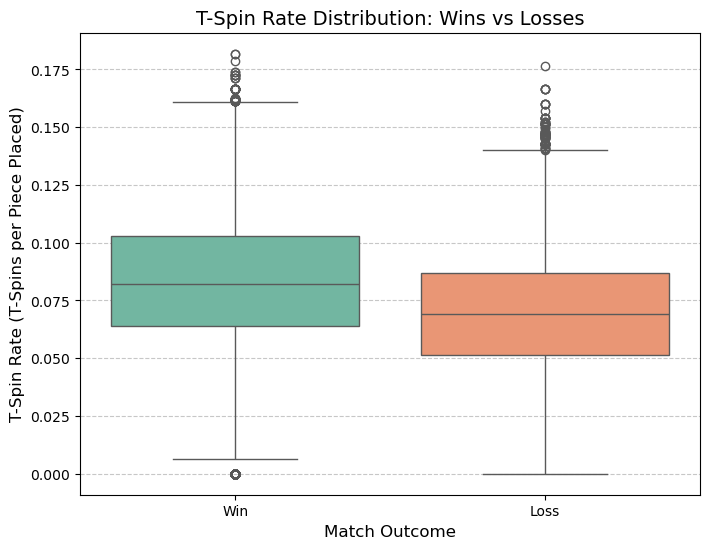

In [53]:
df['won_category'] = df['won'].map({0: 'Loss', 1: 'Win'})

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="won_category",
    y="tspin_rate",
    data=df,
    palette="Set2",
    hue="won_category",
    legend=False
)

plt.title("T-Spin Rate Distribution: Wins vs Losses", fontsize=14)
plt.xlabel("Match Outcome", fontsize=12)
plt.ylabel("T-Spin Rate (T-Spins per Piece Placed)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

df.drop(columns=['won_category'], inplace=True)

### How does the average pressure faced (Incoming Garbage queue) compare between winning and losing games?

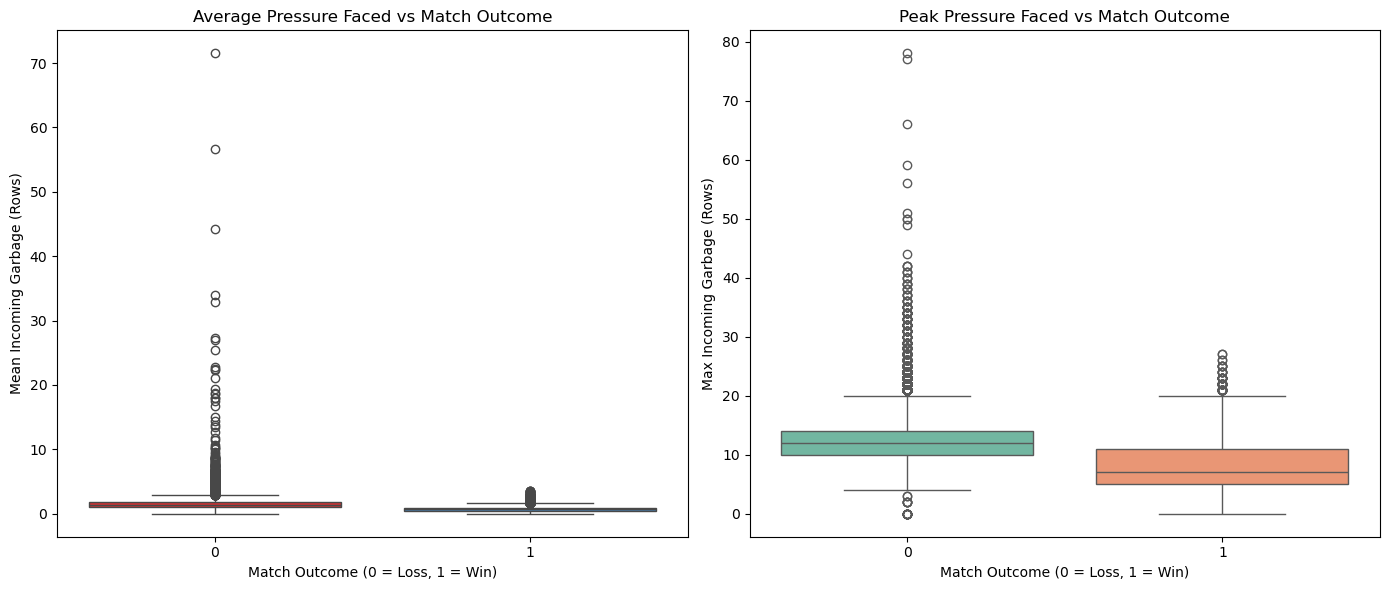

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df,
    x="won",
    y="incoming_garbage_mean",
    hue="won",
    ax=axes[0],
    palette="Set1",
    legend=False
)
axes[0].set_title("Average Pressure Faced vs Match Outcome")
axes[0].set_xlabel("Match Outcome (0 = Loss, 1 = Win)")
axes[0].set_ylabel("Mean Incoming Garbage (Rows)")

sns.boxplot(
    data=df,
    x="won",
    y="incoming_garbage_max",
    hue="won",
    ax=axes[1],
    palette="Set2",
    legend=False
)
axes[1].set_title("Peak Pressure Faced vs Match Outcome")
axes[1].set_xlabel("Match Outcome (0 = Loss, 1 = Win)")
axes[1].set_ylabel("Max Incoming Garbage (Rows)")

plt.tight_layout()

plt.show()

### Is there a linear relationship between a player's raw speed (PPS) and their damage output (APM)?

Pearson Correlation Coefficient (r): 0.672
P-value: 0.000e+00


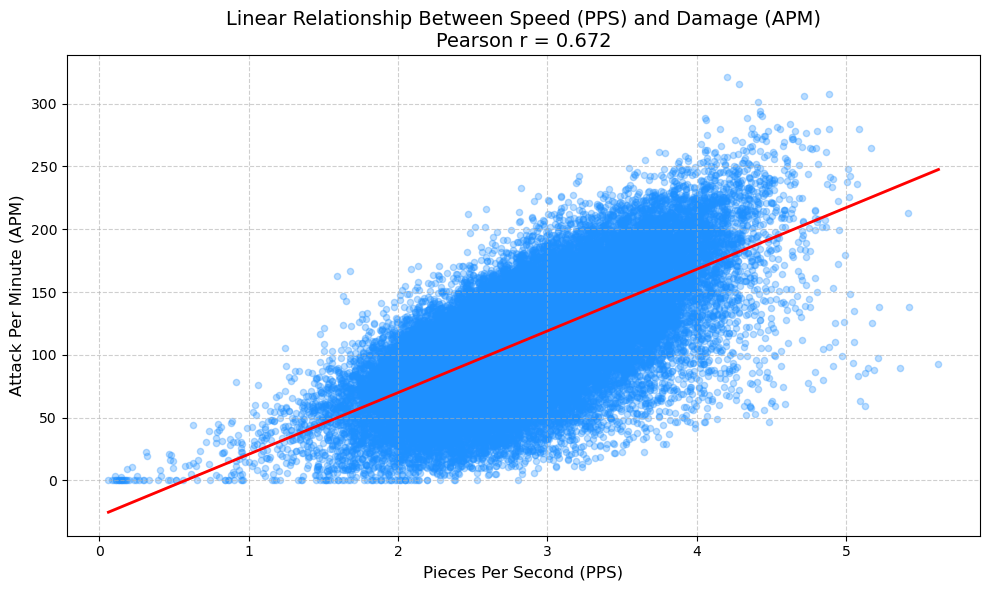

In [55]:

corr, p_value = pearsonr(df['pps'], df['apm'])
print(f"Pearson Correlation Coefficient (r): {corr:.3f}")
print(f"P-value: {p_value:.3e}")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='pps',
    y='apm',
    scatter_kws={'alpha': 0.3, 'color': 'dodgerblue', 's': 20},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title(f"Linear Relationship Between Speed (PPS) and Damage (APM)\nPearson r = {
          corr:.3f}", fontsize=14)
plt.xlabel("Pieces Per Second (PPS)", fontsize=12)
plt.ylabel("Attack Per Minute (APM)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Does relying heavily on maximum combo chains correlate with higher Back-to-Back (B2B) chains?

Pearson Correlation between Max Combo and Max B2B: -0.0088


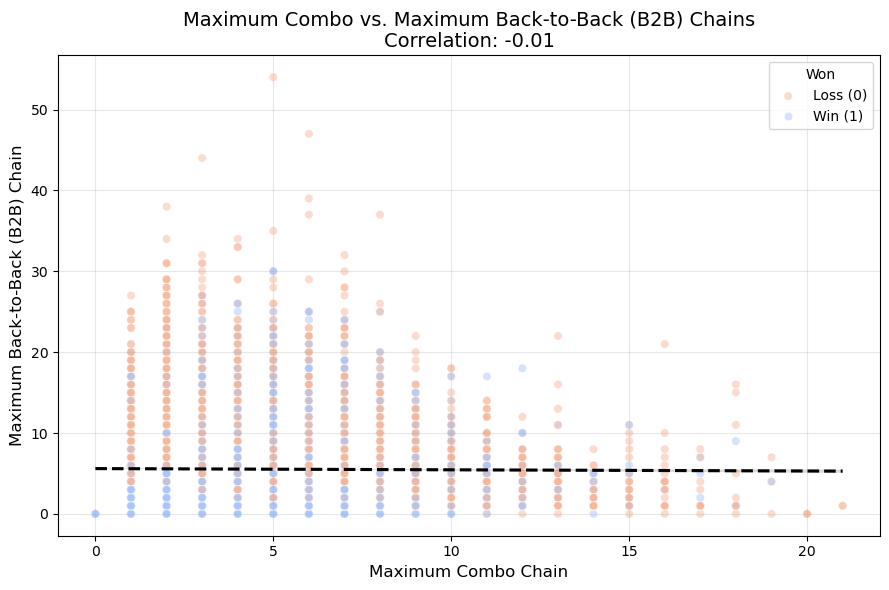

In [56]:
correlation = df["combo_max"].corr(df["btb_max"])
print(f"Pearson Correlation between Max Combo and Max B2B: {correlation:.4f}")

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="combo_max",
    y="btb_max",
    hue="won",
    alpha=0.5,
    palette="coolwarm"
)

sns.regplot(
    data=df,
    x="combo_max",
    y="btb_max",
    scatter=False,
    color='black',
    line_kws={"linestyle": "--"}
)

plt.title(f"Maximum Combo vs. Maximum Back-to-Back (B2B) Chains\nCorrelation: {
          correlation:.2f}", fontsize=14)
plt.xlabel("Maximum Combo Chain", fontsize=12)
plt.ylabel("Maximum Back-to-Back (B2B) Chain", fontsize=12)
plt.legend(title="Won", labels=["Loss (0)", "Win (1)"])
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### When plotting Speed (PPS) against Attack (APM), do winning games cluster in a specific region compared to losing games?

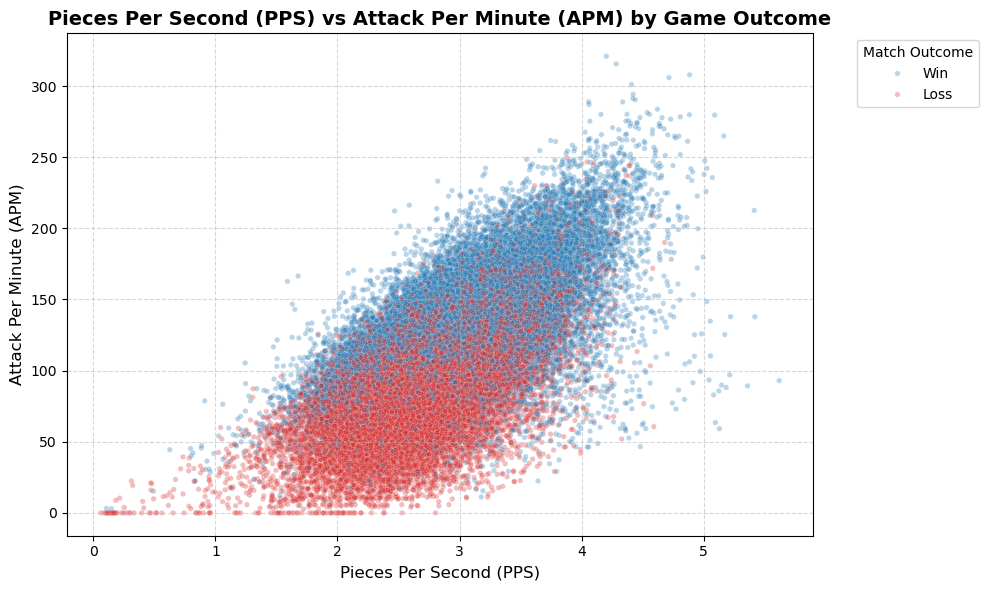

In [57]:
df['Outcome'] = df['won'].map({1: 'Win', 0: 'Loss'})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='pps',
    y='apm',
    hue='Outcome',
    palette={'Win': '#1f77b4', 'Loss': '#d62728'},
    alpha=0.3,
    s=15
)

plt.title('Pieces Per Second (PPS) vs Attack Per Minute (APM) by Game Outcome',
          fontsize=14, fontweight='bold')
plt.xlabel('Pieces Per Second (PPS)', fontsize=12)
plt.ylabel('Attack Per Minute (APM)', fontsize=12)

plt.legend(title='Match Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

df.drop(columns=['Outcome'], inplace=True)